In [ ]:
import pandas as pd

df = pd.read_csv("/content/HHS_Unaccompanied_Alien_Children_Program.csv")

df.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,"December 21, 2025",6.0,18.0,11.0,"2,484",14.0
1,"December 18, 2025",11.0,50.0,6.0,"2,472",16.0
2,"December 17, 2025",7.0,31.0,11.0,"2,481",10.0
3,"December 16, 2025",8.0,54.0,15.0,"2,468",9.0
4,"December 15, 2025",11.0,42.0,9.0,"2,470",7.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1170 entries, 0 to 1169
Data columns (total 6 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Date                                             720 non-null    object 
 1   Children apprehended and placed in CBP custody*  720 non-null    float64
 2   Children in CBP custody                          720 non-null    float64
 3   Children transferred out of CBP custody          720 non-null    float64
 4   Children in HHS Care                             720 non-null    object 
 5   Children discharged from HHS Care                720 non-null    float64
dtypes: float64(4), object(2)
memory usage: 55.0+ KB


In [ ]:
df.describe()

,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children discharged from HHS Care
count,720.000000,720.000000,720.000000,720.000000
mean,93.523611,171.494444,128.668056,173.406944
std,72.646625,126.354965,97.322012,125.702841
min,0.000000,7.000000,0.000000,0.000000
25%,12.000000,36.000000,14.000000,19.750000
50%,99.000000,193.000000,157.000000,181.000000
75%,147.250000,263.250000,199.250000,267.000000
max,333.000000,531.000000,440.000000,505.000000


In [ ]:
df.isnull().sum()

,0
Date,450
Children apprehended and placed in CBP custody*,450
Children in CBP custody,450
Children transferred out of CBP custody,450
Children in HHS Care,450
Children discharged from HHS Care,450


In [ ]:
df.tail()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care,Transfer Efficiency Ratio
1165,NaT,NaN,NaN,NaN,NaN,NaN,NaN
1166,NaT,NaN,NaN,NaN,NaN,NaN,NaN
1167,NaT,NaN,NaN,NaN,NaN,NaN,NaN
1168,NaT,NaN,NaN,NaN,NaN,NaN,NaN
1169,NaT,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df = df.dropna(how='all')

In [ ]:
df.shape

(720, 7)

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 720 entries, 719 to 0
Data columns (total 7 columns):
 #   Column                                           Non-Null Count  Dtype         
---  ------                                           --------------  -----         
 0   Date                                             720 non-null    datetime64[ns]
 1   Children apprehended and placed in CBP custody*  720 non-null    float64       
 2   Children in CBP custody                          720 non-null    float64       
 3   Children transferred out of CBP custody          720 non-null    float64       
 4   Children in HHS Care                             720 non-null    object        
 5   Children discharged from HHS Care                720 non-null    float64       
 6   Transfer Efficiency Ratio                        720 non-null    float64       
dtypes: datetime64[ns](1), float64(5), object(1)
memory usage: 45.0+ KB


In [ ]:
df['Children in HHS Care'].head()

,Children in HHS Care
719,"6,566"
718,"7,122"
717,"7,280"
716,"7,433"
715,"7,538"


In [ ]:
df['Children in HHS Care'].sample(10)

,Children in HHS Care
564,"10,492"
259,"6,061"
81,"1,981"
151,"2,335"
582,"8,914"
198,"2,391"
285,"6,077"
641,"8,572"
128,"2,516"
577,"9,921"


In [ ]:
df['Children in HHS Care'] = (
    df['Children in HHS Care']
    .astype(str)
    .str.replace(',', '')
)

In [ ]:
df['Children in HHS Care'] = pd.to_numeric(
    df['Children in HHS Care']
)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 720 entries, 719 to 0
Data columns (total 7 columns):
 #   Column                                           Non-Null Count  Dtype         
---  ------                                           --------------  -----         
 0   Date                                             720 non-null    datetime64[ns]
 1   Children apprehended and placed in CBP custody*  720 non-null    float64       
 2   Children in CBP custody                          720 non-null    float64       
 3   Children transferred out of CBP custody          720 non-null    float64       
 4   Children in HHS Care                             720 non-null    int64         
 5   Children discharged from HHS Care                720 non-null    float64       
 6   Transfer Efficiency Ratio                        720 non-null    float64       
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 45.0 KB


In [ ]:
print(df['Date'].min())
print(df['Date'].max())

2023-01-12 00:00:00
2025-12-21 00:00:00


In [ ]:
import os

os.makedirs("screenshots", exist_ok=True)

def save_graph(name):
    plt.savefig(f"screenshots/{name}.png", bbox_inches="tight")

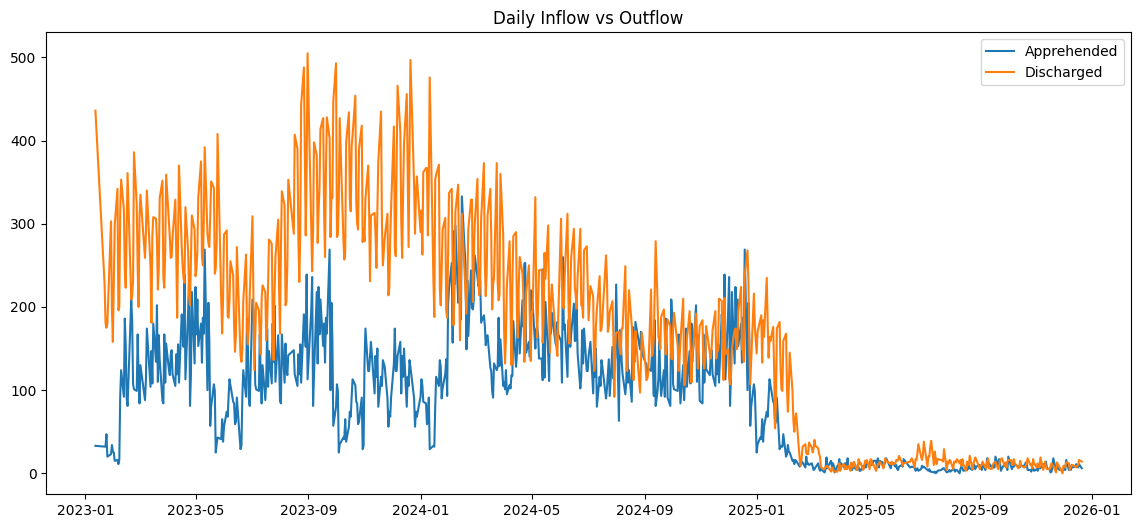

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(
    df['Date'],
    df['Children apprehended and placed in CBP custody*'],
    label='Apprehended'
)

plt.plot(
    df['Date'],
    df['Children discharged from HHS Care'],
    label='Discharged'
)

plt.legend()
plt.title('Daily Inflow vs Outflow')
save_graph("Daily Inflow vs Outflow")

plt.show()

In [ ]:
df.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care,Transfer Efficiency Ratio
719,2023-01-12,33.0,53.0,34.0,6566,436.0,0.641509
718,2023-01-22,32.0,49.0,39.0,7122,227.0,0.795918
717,2023-01-23,32.0,50.0,39.0,7280,181.0,0.780000
716,2023-01-24,47.0,42.0,47.0,7433,175.0,1.119048
715,2023-01-25,20.0,22.0,41.0,7538,180.0,1.863636


In [ ]:
df = df.sort_values('Date').reset_index(drop=True)
df.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care,Transfer Efficiency Ratio
0,2023-01-12,33.0,53.0,34.0,6566,436.0,0.641509
1,2023-01-22,32.0,49.0,39.0,7122,227.0,0.795918
2,2023-01-23,32.0,50.0,39.0,7280,181.0,0.780000
3,2023-01-24,47.0,42.0,47.0,7433,175.0,1.119048
4,2023-01-25,20.0,22.0,41.0,7538,180.0,1.863636


In [ ]:
df['Transfer Efficiency Ratio'] = (
    df['Children transferred out of CBP custody']
    /
    df['Children in CBP custody']
)

In [ ]:
df['Discharge Effectiveness'] = (
    df['Children discharged from HHS Care']
    /
    df['Children in HHS Care']
)

In [ ]:
df['Pipeline Throughput'] = (
    df['Children discharged from HHS Care']
    /
    df['Children apprehended and placed in CBP custody*']
)

In [ ]:
import numpy as np

df.replace([np.inf, -np.inf], np.nan, inplace=True)

In [ ]:
df['Backlog'] = (
    df['Children apprehended and placed in CBP custody*']
    -
    df['Children discharged from HHS Care']
)

In [ ]:
df['Backlog_7Day'] = (
    df['Backlog']
    .rolling(7)
    .mean()
)

In [ ]:
df['Outcome Stability'] = (
    df['Children discharged from HHS Care']
    .rolling(7)
    .std()
)

In [ ]:
kpis = [
    'Transfer Efficiency Ratio',
    'Discharge Effectiveness',
    'Pipeline Throughput',
    'Backlog'
]

df[kpis].describe()

,Transfer Efficiency Ratio,Discharge Effectiveness,Pipeline Throughput,Backlog
count,720.000000,720.000000,718.000000,720.000000
mean,0.691018,0.023737,2.503247,-79.883333
std,0.309811,0.013310,2.470397,98.048725
min,0.000000,0.000000,0.000000,-447.000000
25%,0.500000,0.008616,1.152592,-139.250000
50%,0.704449,0.026297,1.779040,-48.500000
75%,0.846429,0.032939,2.878137,-4.000000
max,2.300000,0.066403,21.375000,121.000000


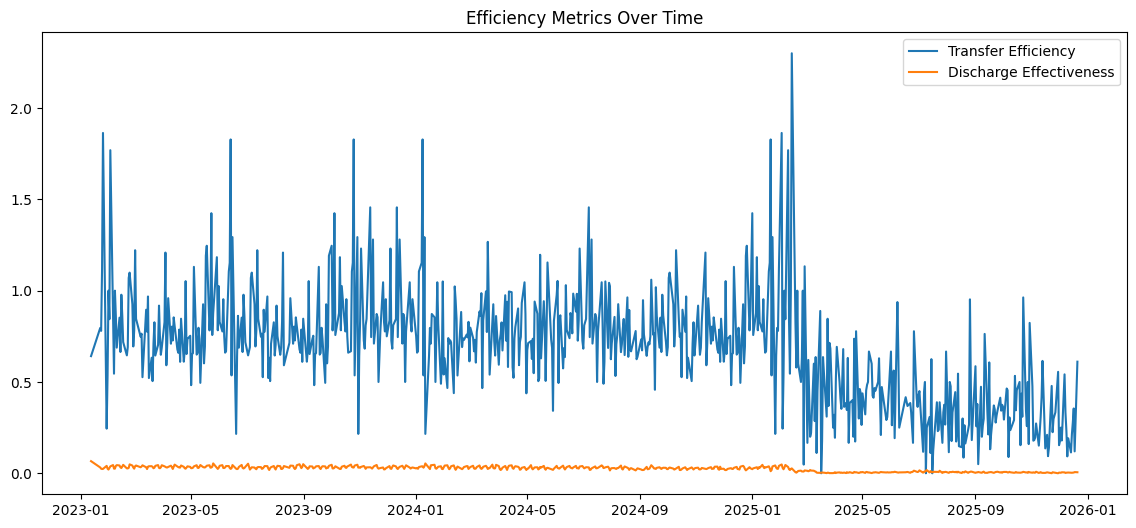

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(
    df['Date'],
    df['Transfer Efficiency Ratio'],
    label='Transfer Efficiency'
)

plt.plot(
    df['Date'],
    df['Discharge Effectiveness'],
    label='Discharge Effectiveness'
)

plt.legend()
plt.title('Efficiency Metrics Over Time')
save_graph("Efficiency Metrics Over Time")

plt.show()

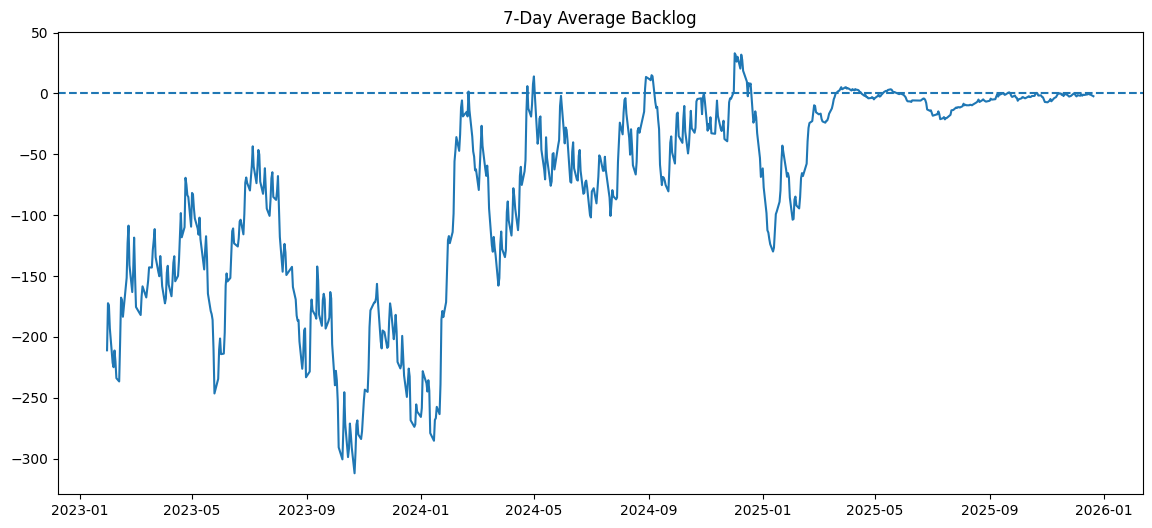

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(
    df['Date'],
    df['Backlog_7Day']
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.title('7-Day Average Backlog')
save_graph("7-Day Average Backlog")

plt.show()

In [ ]:
df[
[
'Transfer Efficiency Ratio',
'Discharge Effectiveness',
'Pipeline Throughput',
'Backlog'
]
].describe()

,Transfer Efficiency Ratio,Discharge Effectiveness,Pipeline Throughput,Backlog
count,720.000000,720.000000,718.000000,720.000000
mean,0.691018,0.023737,2.503247,-79.883333
std,0.309811,0.013310,2.470397,98.048725
min,0.000000,0.000000,0.000000,-447.000000
25%,0.500000,0.008616,1.152592,-139.250000
50%,0.704449,0.026297,1.779040,-48.500000
75%,0.846429,0.032939,2.878137,-4.000000
max,2.300000,0.066403,21.375000,121.000000


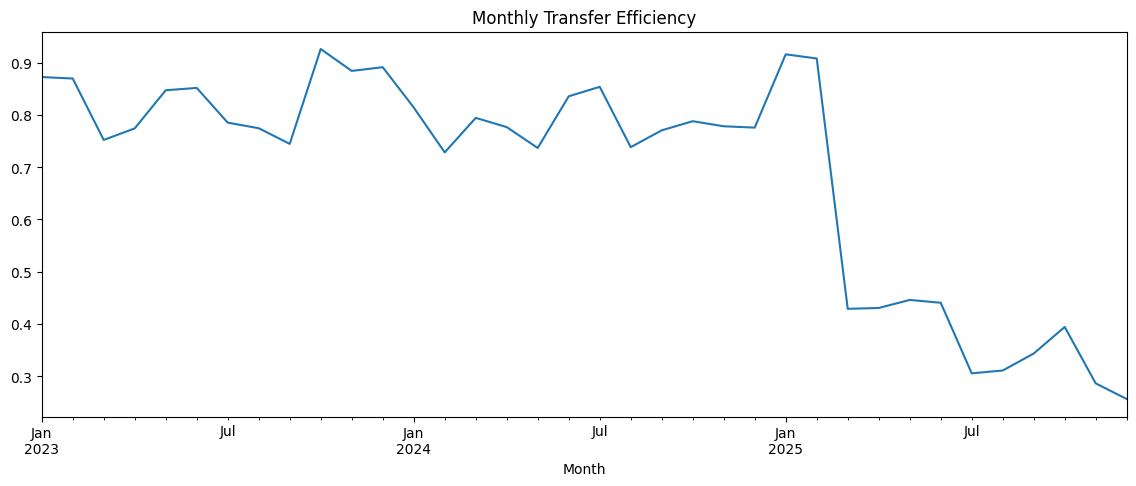

In [ ]:
df['Month'] = df['Date'].dt.to_period('M')
monthly_transfer = (
    df.groupby('Month')
    ['Transfer Efficiency Ratio']
    .mean()
)
monthly_transfer.plot(
    figsize=(14,5),
    title='Monthly Transfer Efficiency'
)
save_graph("Monthly Transfer Efficiency")
plt.show()

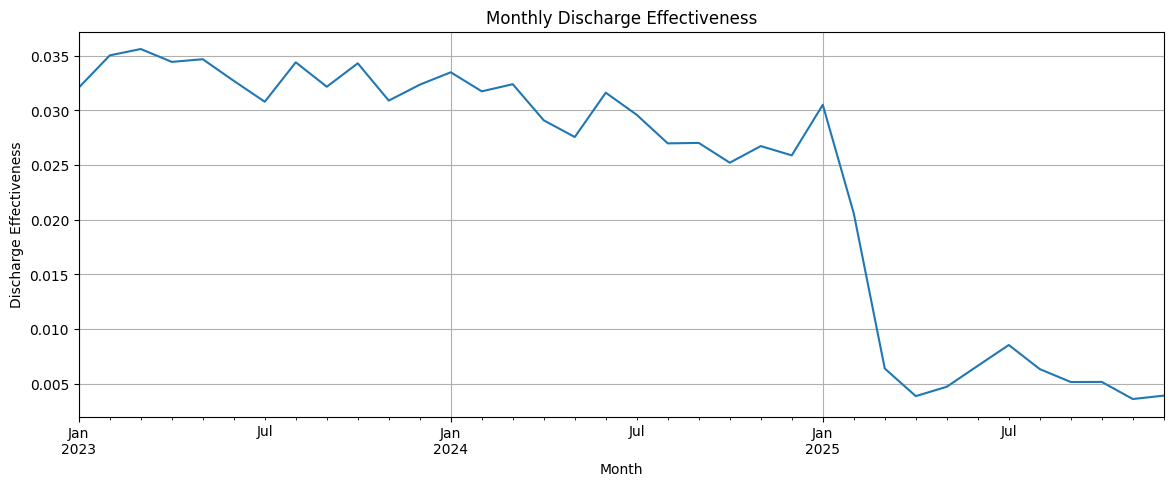

In [ ]:
monthly_discharge = (
    df.groupby('Month')
    ['Discharge Effectiveness']
    .mean()
)

plt.figure(figsize=(14,5))

monthly_discharge.plot()

plt.title('Monthly Discharge Effectiveness')
plt.ylabel('Discharge Effectiveness')
plt.xlabel('Month')

plt.grid(True)
save_graph("Monthly  Discharge Efficiency")
plt.show()

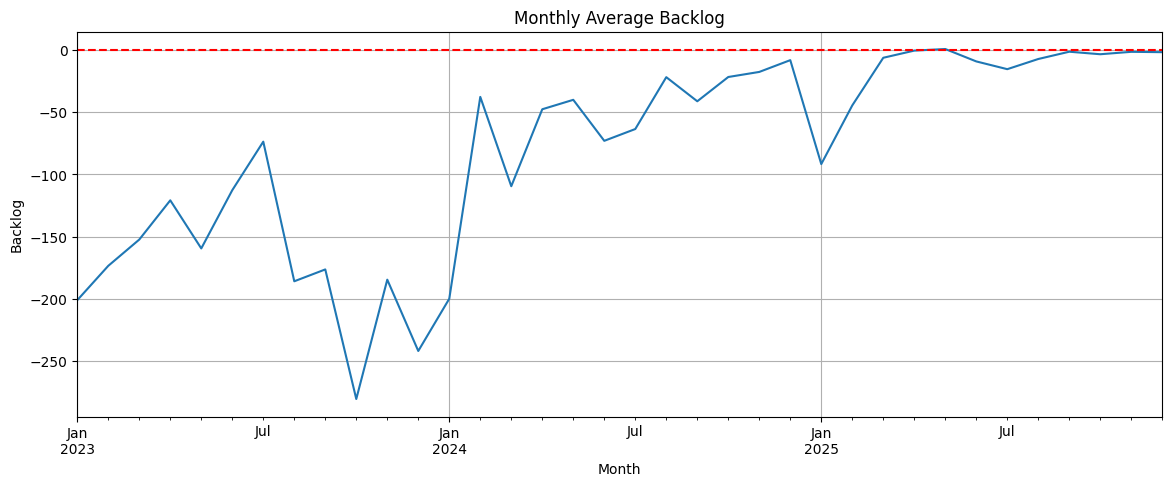

In [ ]:
monthly_backlog = (
    df.groupby('Month')
    ['Backlog']
    .mean()
)

plt.figure(figsize=(14,5))

monthly_backlog.plot()

plt.axhline(
    y=0,
    linestyle='--',
    color='red'
)

plt.title('Monthly Average Backlog')
plt.ylabel('Backlog')
plt.xlabel('Month')

plt.grid(True)
save_graph("Monthly Average Backlog")
plt.show()

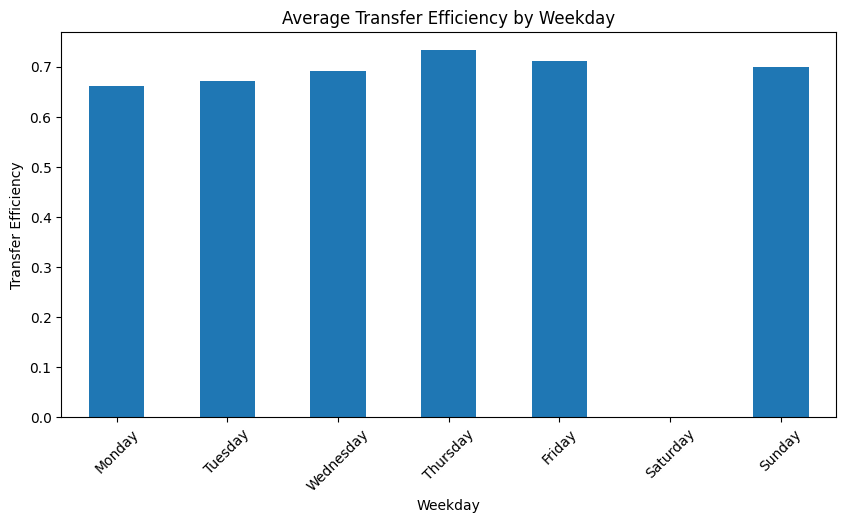

In [ ]:
df['Weekday'] = df['Date'].dt.day_name()

order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

weekday_transfer = (
    df.groupby('Weekday')
    ['Transfer Efficiency Ratio']
    .mean()
)

weekday_transfer = weekday_transfer.reindex(order)

plt.figure(figsize=(10,5))

weekday_transfer.plot(kind='bar')

plt.title('Average Transfer Efficiency by Weekday')
plt.ylabel('Transfer Efficiency')
plt.xlabel('Weekday')

plt.xticks(rotation=45)
save_graph("Average Transfer Efficiency by Weekday")
plt.show()

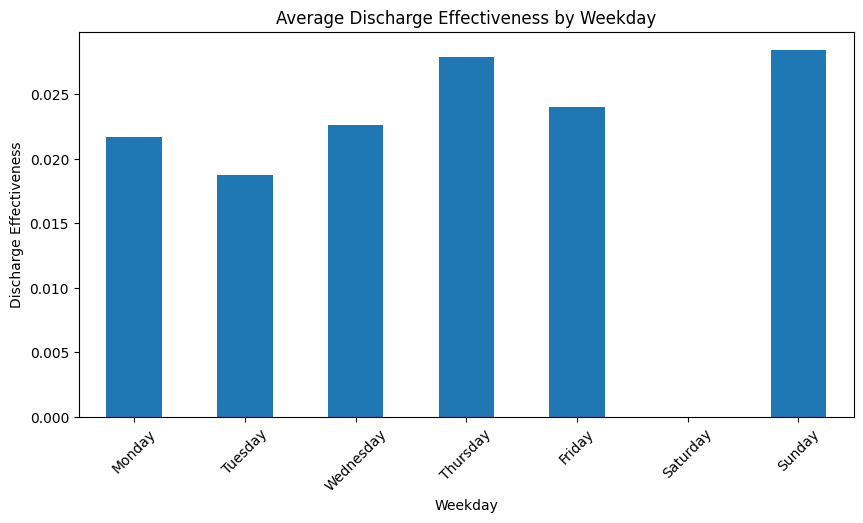

In [ ]:
weekday_discharge = (
    df.groupby('Weekday')
    ['Discharge Effectiveness']
    .mean()
)

weekday_discharge = weekday_discharge.reindex(order)

plt.figure(figsize=(10,5))

weekday_discharge.plot(kind='bar')

plt.title('Average Discharge Effectiveness by Weekday')
plt.ylabel('Discharge Effectiveness')
plt.xlabel('Weekday')

plt.xticks(rotation=45)
save_graph("Average Discharge Efficiency by Weekday")
plt.show()

In [ ]:
df['Health Score'] = (
    df['Transfer Efficiency Ratio'] * 40
    +
    df['Discharge Effectiveness'] * 40
    +
    df['Pipeline Throughput'] * 20
)

df['Health Score'] = (
    df['Health Score']
    /
    df['Health Score'].max()
) * 100

print("Average Health Score:",
      round(df['Health Score'].mean(),2))

Average Health Score: 16.75


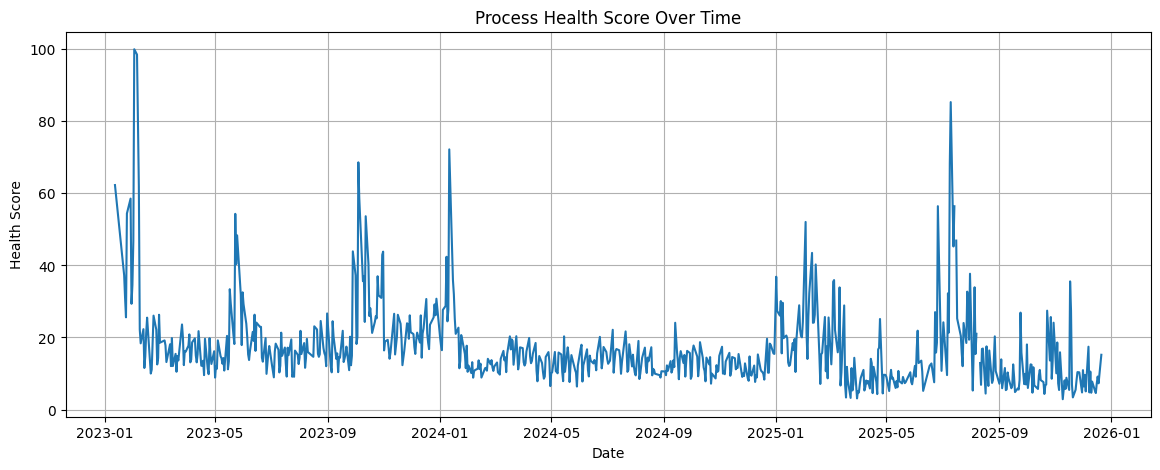

In [ ]:
plt.figure(figsize=(14,5))

plt.plot(
    df['Date'],
    df['Health Score']
)

plt.title('Process Health Score Over Time')
plt.ylabel('Health Score')
plt.xlabel('Date')

plt.grid(True)
save_graph("Process Health Score Over Time")
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


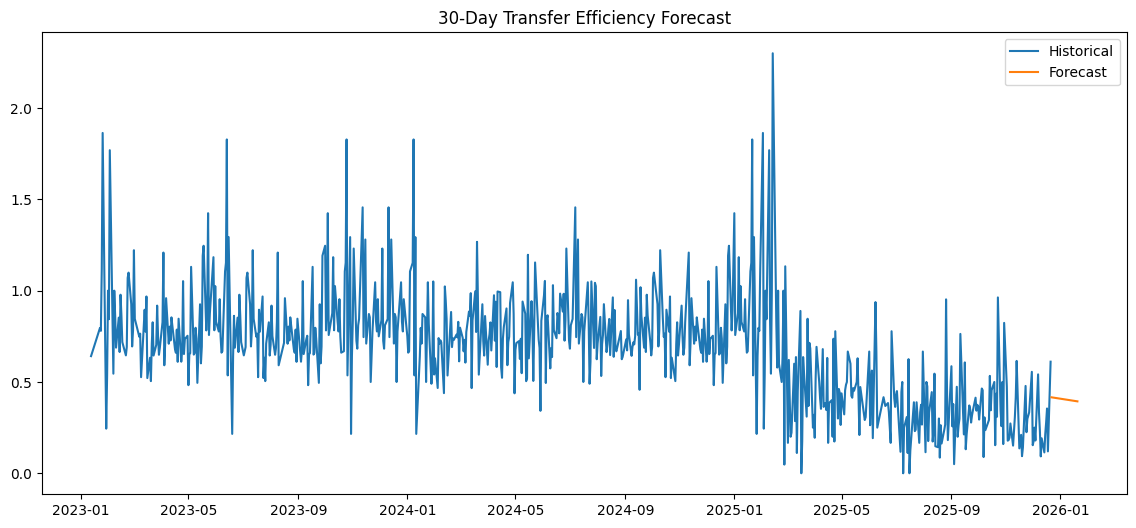

In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np
forecast_df = df[['Date','Transfer Efficiency Ratio']].copy()

forecast_df['Day_Number'] = np.arange(len(forecast_df))
X = forecast_df[['Day_Number']]
y = forecast_df['Transfer Efficiency Ratio']

model = LinearRegression()
model.fit(X,y)
future_days = np.arange(
    len(forecast_df),
    len(forecast_df)+30
).reshape(-1,1)

future_pred = model.predict(future_days)
future_dates = pd.date_range(
    start=df['Date'].max()+pd.Timedelta(days=1),
    periods=30
)
plt.figure(figsize=(14,6))

plt.plot(
    df['Date'],
    df['Transfer Efficiency Ratio'],
    label='Historical'
)

plt.plot(
    future_dates,
    future_pred,
    label='Forecast'
)

plt.legend()

plt.title('30-Day Transfer Efficiency Forecast')

save_graph("Transfer_Efficiency_Forecast")

plt.show()